# EDA e definição do alvo

Tech Challenge Fase 3. Unidade de análise: município em 2024. Alvo: `nao_atingiu_meta`.
Detalhes em `reports/01_eda_e_definicao_alvo.md`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..')
base = pd.read_parquet(ROOT / 'data' / 'silver' / 'municipio_ano_integrada.parquet')
modelo = pd.read_parquet(ROOT / 'data' / 'silver' / 'base_modelo.parquet')
print(base.shape, 'anos', sorted(base['ano'].unique().tolist()))
print('modelo 2024', modelo.shape, 'positivo', modelo['nao_atingiu_meta'].mean().round(3))

(10896, 11) anos [2023, 2024]
modelo 2024 (5232, 30) positivo 0.467


## Qualidade e geografia

Bater a meta não é ter taxa alta. O Sul tem barra mais exigente; o Centro-Oeste cumpre mais com taxa semelhante.

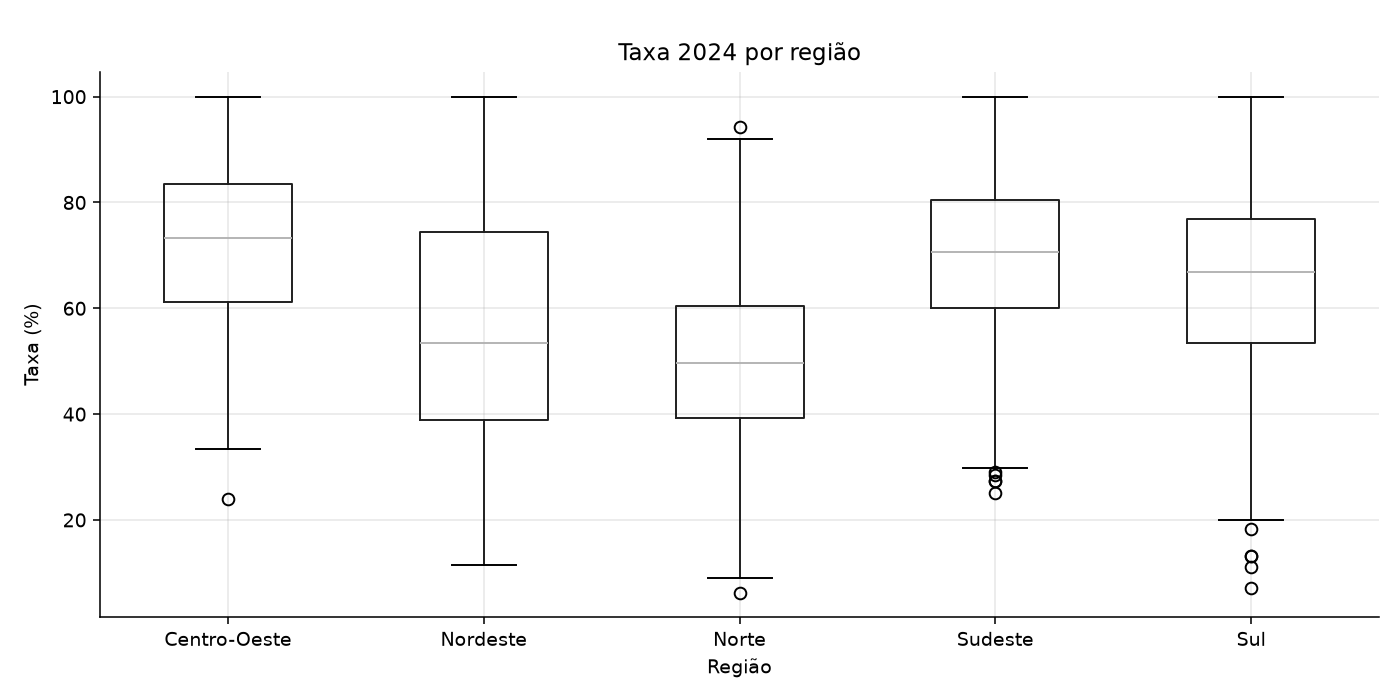

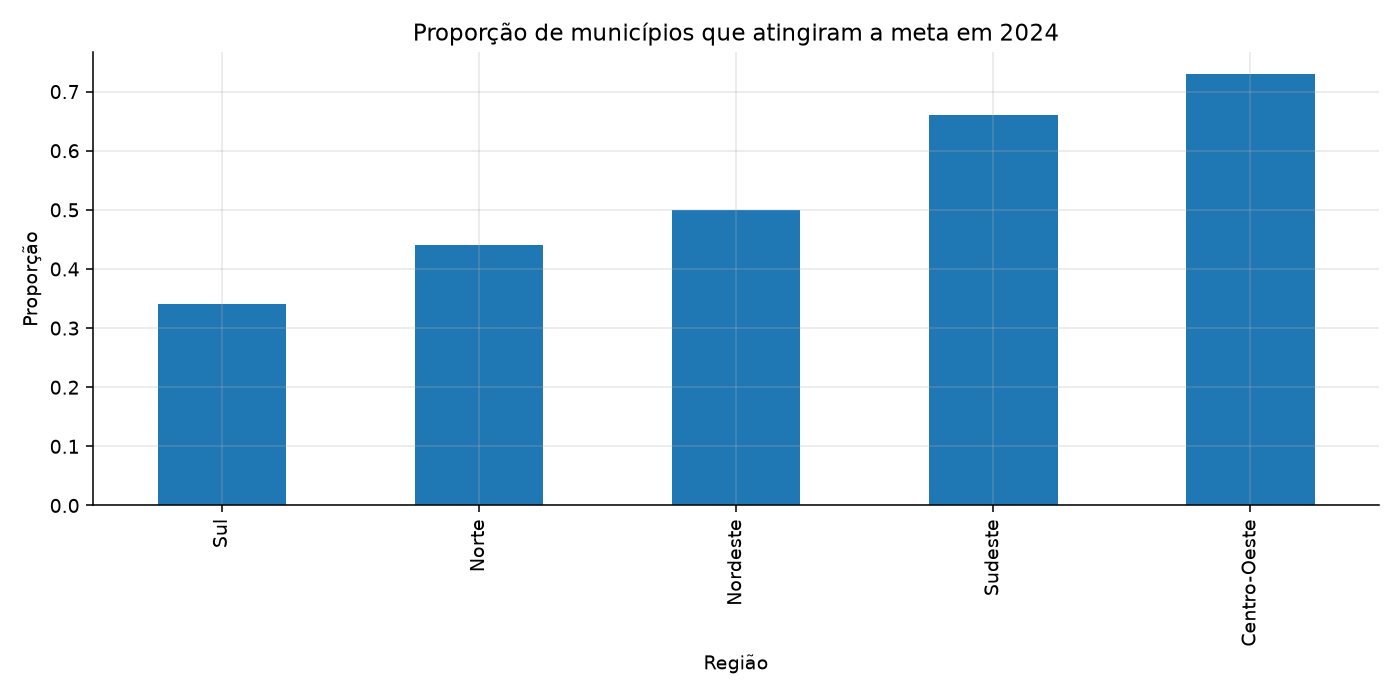

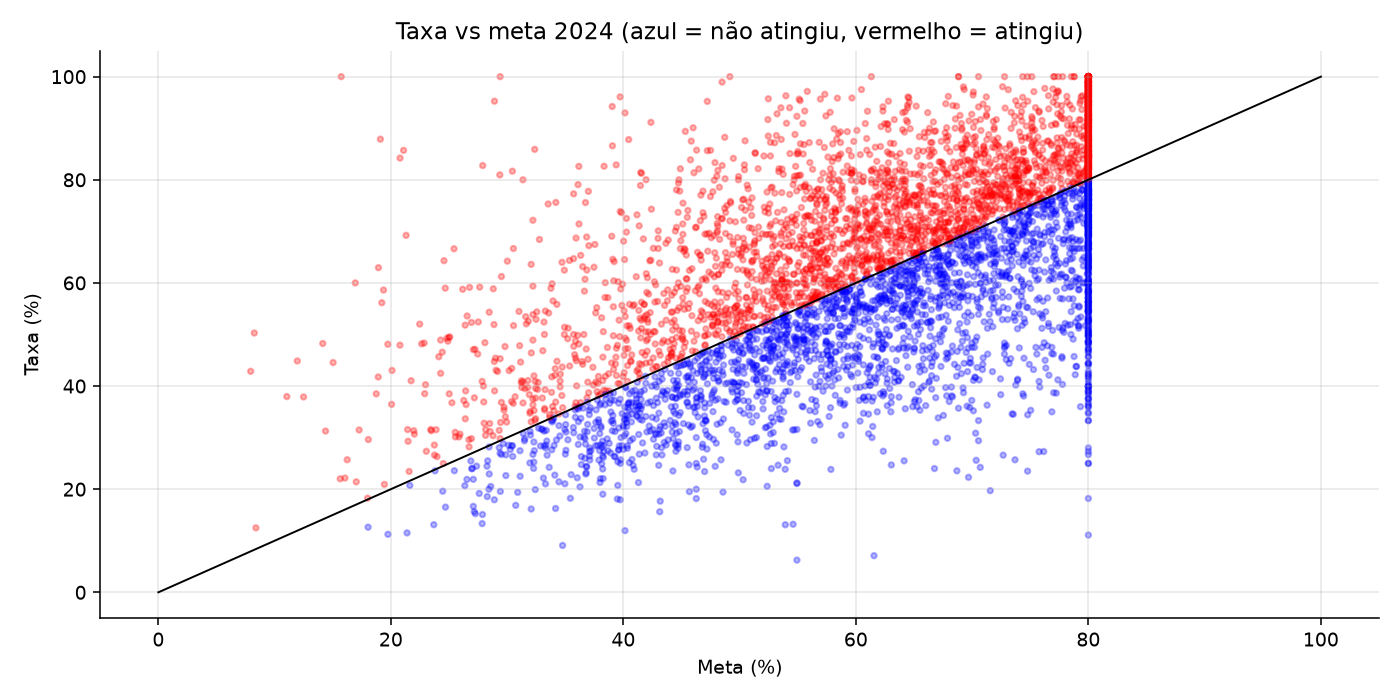

In [2]:
display(Image(ROOT / 'images' / 'eda' / '03_taxa_por_regiao.png'))
display(Image(ROOT / 'images' / 'eda' / '04_prop_meta_por_regiao.png'))
display(Image(ROOT / 'images' / 'eda' / '06_taxa_vs_meta.png'))

In [3]:
pd.read_csv(ROOT / 'reports' / 'eda_por_regiao.csv')

,regiao,n,taxa_media,meta_media,prop_na_meta,taxa_2023
0,Sul,1054,64.68,72.31,0.34,72.92
1,Norte,389,50.24,50.95,0.44,46.13
2,Nordeste,1738,56.78,55.67,0.50,53.56
3,Sudeste,1590,69.98,64.23,0.66,62.15
4,Centro-Oeste,461,72.32,65.63,0.73,64.53


## Vazamento

`media_portugues` correlaciona 0,92 com a taxa. Meta 2024 correlaciona 0,98 com a taxa de 2023. Essas colunas do mesmo ciclo não entram no `X`.